Rotor Radi + Road Distance

There are online websites to see what the LCoE was for EU countries.

For calculating Spot Price, we need WS, WS is the Wind Speed.

# Import Packages

In [4533]:
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import yaml
from scipy.stats import weibull_min
from shapely.geometry import Point, Polygon, LineString
from shapely.ops import unary_union
from floris import FlorisModel
from floris.wind_data import WindRose
import floris as _floris_pkg

# Path to FLORIS built-in default GCH config
_FLORIS_DEFAULT_YAML = str(
    pathlib.Path(_floris_pkg.__file__).parent / 'default_inputs.yaml'
)
print('FLORIS', _floris_pkg.__version__, '-- default yaml found:', _FLORIS_DEFAULT_YAML)

# Turbine Properties

In [4534]:
turbines = ["iea_3p4MW", "bar_bau_iea_3p3MW", "bar_bau_lsp_3p25MW"]
HUB_HEIGHT = 120

# Denmark Site

## Plotting Map

### Conversion to KM

In [4535]:
lattitude_degree_to_km = 111
longitude_degree_to_km_at_55 = 63

### Helper Function

In [4536]:
def get_ref(stri):
    # This is using the DMS format - Degree Minutes Seconds
    
	lattLB = 55 + (14/60) + (39.2/(3600))
	longLB = 9 + (00/60) + (41.3/(3600))

	latt_deg = float(stri.strip().split("°")[0])
	latt_min = float(stri.strip().split("'")[0].split("°")[1])
	latt_sec = float(stri.strip().split("\"")[0].split("°")[1].split("'")[1].replace("\\", ""))

	long_deg = float(stri.strip().split("N")[1].split("°")[0])
	long_min = float(stri.strip().split("N")[1].split("'")[0].split("°")[1])
	long_sec = float(stri.strip().split("N")[1].split("\"")[0].split("°")[1].split("'")[1].replace("\\", ""))

	latt = latt_deg + (latt_min/60) + (latt_sec/(3600))
	long = long_deg + (long_min/60) + (long_sec/(3600))
 
	latt = (latt - lattLB) * lattitude_degree_to_km
 
	long = (long - longLB) * longitude_degree_to_km_at_55

	return latt, long

In [4537]:
def get_ref_WGS84(latt, long):
    # This is using the WGS84 lattitude/longitude form.
    
	lattLB = 55 + (14/60) + (39.2/(3600))
	longLB = 9 + (00/60) + (41.3/(3600))
 
	latt = (latt - lattLB) * lattitude_degree_to_km
 
	long = (long - longLB) * longitude_degree_to_km_at_55

	return latt, long

### Boundaries

In [4538]:
# Left Bottom
lattLB, longLB = get_ref(r"55°14'39.2\"N 9°00'41.3\"E")
# Right Bottom
lattRB, longRB = get_ref(r"55°14'53.8\"N 9°03'30.7\"E")
# Left Top
lattLT, longLT =  get_ref(r"55°15'48.1\"N 9°00'48.7\"E")
# Right Top
lattRT, longRT =  get_ref(r"55°15'41.7\"N 9°04'04.8\"E")

lattLB, lattRB, lattLT, lattRT, longLB, longRB, longLT, longRT

(0.0,
 0.4501666666671511,
 2.1244166666667326,
 1.9270833333336839,
 0.0,
 2.9645000000000046,
 0.12950000000000905,
 3.561249999999969)

### Roads

#### Kastrupvej

In [4539]:
lat_k_start, lon_k_start = get_ref(r"55°14'39.2\"N 9°00'41.3\"E")
lat_k_1, lon_k_1 = get_ref(r"55°14'49.0\"N 9°02'23.0\"E")
lat_k_2, lon_k_2 = get_ref(r"55°14'53.0\"N 9°02'60.0\"E")
lat_k_end, lon_k_end = get_ref(r"55°15'03.6\"N 9°03'38.0\"E")

#### Toftlundvej

In [4540]:
lat_t_start, lon_t_start = get_ref(r"55°15'47.1\"N 9°02'07.5\"E")
lat_t_end, lon_t_end = get_ref(r"55°14'42.8\"N 9°02'24.7\"E")

#### Marbaekgardvej

In [4541]:
lat_m_start, lon_m_start = get_ref(r"55°15'19.4\"N 9°02'15.0\"E")
lat_m_1, lon_m_1 = get_ref(r"55°15'18.0\"N 9°02'30.4\"E")
lat_m_2, lon_m_2 = get_ref(r"55°15'33.2\"N 9°02'35.7\"E")
lat_m_3, lon_m_3 = get_ref(r"55°15'54.6\"N 9°02'49.1\"E")
lat_m_4, lon_m_4 = get_ref(r"55°15'46.0\"N 9°02'43.7\"E")
lat_m_5, lon_m_5 = get_ref(r"55°15'45.0\"N 9°02'50.1\"E")
lat_m_6, lon_m_6 = get_ref(r"55°15'45.6\"N 9°02'54.6\"E")
lat_m_7, lon_m_7 = get_ref(r"55°15'43.3\"N 9°03'10.5\"E")
lat_m_end, lon_m_end = get_ref(r"55°15'54.6\"N 9°02'49.1\"E")

#### Udsigtsvejen

In [4542]:
lat_u_start, lon_u_start = get_ref(r"55°15'41.7\"N 9°04'04.8\"E")
lat_u_1, lon_u_1 = get_ref(r"55°15'41.9\"N 9°03'46.7\"E")
lat_u_2, lon_u_2 = get_ref(r"55°15'49.5\"N 9°03'18.2\"E")
lat_u_end, lon_u_end = get_ref(r"55°15'54.6\"N 9°02'49.1\"E")

#### Stensvejen

In [4543]:
lat_s_start, lon_s_start = get_ref(r"55°15'02.2\"N 9°02'19.4\"E")
lat_s_end, lon_s_end = get_ref(r"55°15'07.4\"N 9°00'48.6\"E")

#### Engvej

In [4544]:
lat_e_start, lon_e_start = get_ref(r"55°15'48.1\"N 9°00'48.7\"E")
lat_e_1, lon_e_1 = get_ref(r"55°15'07.4\"N 9°00'48.6\"E")
lat_e_end, lon_e_end = get_ref(r"55°14'39.2\"N 9°00'41.3\"E")

### Town

#### Kastrup

In [4545]:
lat_k_town, lon_k_town = get_ref(r"55°15'46.7\"N 9°04'46.7\"E")

### Buildings

In [4546]:
builds = []

#### Preben Gad

In [4547]:
builds.append(get_ref_WGS84(55.26376264248587, 9.056352828928594))

#### Marbækgårdvej 1

In [4548]:
builds.append(get_ref_WGS84(55.26231259217023, 9.050049639108959))

#### Udsigtsvejen 16

In [4549]:
builds.append(get_ref_WGS84(55.2646173108904, 9.053834297505002))

#### Udsigtsvejen 15

In [4550]:
builds.append(get_ref_WGS84(55.26411229432016, 9.051162083724197))

#### Udsigtsvejen 18

In [4551]:
builds.append(get_ref_WGS84(55.26576740553818, 9.051293190948849))

#### Udsigtsvejen 17

In [4552]:
builds.append(get_ref_WGS84(55.264889460129645, 9.045758966509334))

#### Marbækvej 6


In [4553]:
builds.append(get_ref_WGS84(55.2671271658051, 9.044682957544456))

#### Marbækvej 5

In [4554]:
builds.append(get_ref_WGS84(55.26829141385979, 9.049309200476348))

#### Hinne van der Harst

In [4555]:
# builds.append(get_ref_WGS84(55.24516341841765, 9.001604423465745))

#### Kastrupvej 26

In [4556]:
builds.append(get_ref_WGS84(55.244789869056724, 9.018664063980859))

#### Kastrupvej 24

In [4557]:
builds.append(get_ref_WGS84(55.2442058697137, 9.013678153589987))

#### Feltvej 6

In [4558]:
builds.append(get_ref(r"55°15'34.3\"N 9°03'57.9\"E"))

#### Toftlundvej 2

In [4559]:
# builds.append(get_ref_WGS84(55.27063315298789, 9.032570918783033))

#### Henrik Beck

In [4560]:
builds.append(get_ref_WGS84(55.262889159277975, 9.059533065052847))

#### Udsigtsvejen 13


In [4561]:
builds.append(get_ref_WGS84(55.262144456274946, 9.060026613116126))

#### Random Building

In [4562]:
builds.append(get_ref_WGS84(55.25146667381516, 9.028779460002486))

#### Engvej 21

In [4563]:
builds.append(get_ref_WGS84(55.26772112772359, 9.014694124807043))

### Existing Wind Turbines

#### Kastrupvej

In [4564]:
wts = []

wts.append(get_ref_WGS84(55.2518537387715, 9.067113095780657))
wts.append(get_ref_WGS84(55.25005608478371, 9.065860880416732))
wts.append(get_ref_WGS84(55.24838910327743, 9.064680783026962))
wts.append(get_ref_WGS84(55.24662865506457, 9.063393833038278))

wts.append(get_ref_WGS84(55.25122021158104, 9.070125865365986))
wts.append(get_ref_WGS84(55.24940653519977, 9.068889527809011))
wts.append(get_ref_WGS84(55.2476480890615, 9.067588117653926))
wts.append(get_ref_WGS84(55.24588890783806, 9.066452109190593))

### Plotting

#### Variables

In [4565]:
ROAD_BUFFER_KM = 0.015  # 15m in km

#### Boundaries

In [4566]:
# Boundary Polygon (LB → RB → RT → LT, clockwise)
boundary_x = [longLB, longRB, longRT, longLT]
boundary_y = [lattLB, lattRB, lattRT, lattLT]

#### Read Segments

In [4567]:
road_segments = [
    # Kastrupvej
    ((lon_k_start, lat_k_start), (lon_k_1, lat_k_1)),
    ((lon_k_1,     lat_k_1    ), (lon_k_2, lat_k_2)),
    ((lon_k_2,     lat_k_2    ), (lon_k_end, lat_k_end)),
    # Toftlundvej
    ((lon_t_start, lat_t_start), (lon_t_end, lat_t_end)),
    # Marbaekgardvej
    ((lon_m_start, lat_m_start), (lon_m_1, lat_m_1)),
    ((lon_m_1,     lat_m_1    ), (lon_m_2, lat_m_2)),
    ((lon_m_2,     lat_m_2    ), (lon_m_3, lat_m_3)),
    ((lon_m_4,     lat_m_4    ), (lon_m_5, lat_m_5)),
    ((lon_m_5,     lat_m_5    ), (lon_m_6, lat_m_6)),
    ((lon_m_6,     lat_m_6    ), (lon_m_7, lat_m_7)),
    ((lon_m_4,     lat_m_4    ), (lon_m_end, lat_m_end)),
    # Udsigtsvejen
    ((lon_u_start, lat_u_start), (lon_u_1, lat_u_1)),
    ((lon_u_1,     lat_u_1    ), (lon_u_2, lat_u_2)),
    ((lon_u_2,     lat_u_2    ), (lon_u_end, lat_u_end)),
    # Stensvejen
    ((lon_s_start, lat_s_start), (lon_s_end, lat_s_end)),
    # Engvej
    ((lon_e_start, lat_e_start), (lon_e_1, lat_e_1)),
    ((lon_e_1,     lat_e_1    ), (lon_e_end, lat_e_end)),
]

#### Road Buffer Function

In [4568]:
def road_buffer_polygon(x0, y0, x1, y1, width):
    """Returns the 4 corners of a rectangle buffering a line segment."""
    import numpy as np
    dx, dy = x1 - x0, y1 - y0
    length = np.hypot(dx, dy)
    # Perpendicular unit vector
    px, py = -dy / length, dx / length
    offset = width / 2
    return [
        (x0 + px * offset, y0 + py * offset),
        (x1 + px * offset, y1 + py * offset),
        (x1 - px * offset, y1 - py * offset),
        (x0 - px * offset, y0 - py * offset),
    ]

#### Field Boarders

In [4569]:
fb = []

fb.append(get_ref_WGS84(55.263378079208664, 9.013538798791178))
fb.append(get_ref_WGS84(55.26179918912272, 9.023299488092954))
fb.append(get_ref_WGS84(55.259586009260396, 9.013611349046208))
fb.append(get_ref_WGS84(55.259193935675405, 9.020673691208579))
fb.append(get_ref_WGS84(55.2595214708722, 9.0230302748183))
fb.append(get_ref_WGS84(55.259378271002554, 9.025777960420816))
fb.append(get_ref_WGS84(55.26158955844181, 9.025215304079365))
fb.append(get_ref_WGS84(55.26133286769302, 9.025996682092389))
fb.append(get_ref_WGS84(55.26408211153519, 9.026229682092394))
fb.append(get_ref_WGS84(55.262858338573665, 9.0165206820924))
fb.append(get_ref_WGS84(55.26297458335403, 9.025491682092403))
fb.append(get_ref_WGS84(55.263673866522346, 9.016592317674311))
fb.append(get_ref_WGS84(55.25932834020308, 9.017505682092377))
fb.append(get_ref_WGS84(55.259174200214076, 9.020072631023627))
fb.append(get_ref_WGS84(55.26226868149219, 9.020374153862859))
fb.append(get_ref_WGS84(55.26264444703107, 9.01778336389916))
fb.append(get_ref_WGS84(55.25756314091412, 9.013645153862841))
fb.append(get_ref_WGS84(55.25720245038016, 9.017287363899133))
fb.append(get_ref_WGS84(55.256221450983844, 9.017067363899129))
fb.append(get_ref_WGS84(55.25663427915377, 9.013682635062942))
fb.append(get_ref_WGS84(55.25227933900355, 9.013579761751688))
fb.append(get_ref_WGS84(55.252772510595804, 9.014885728317171))
fb.append(get_ref_WGS84(55.25369862479202, 9.021289363899083))
fb.append(get_ref_WGS84(55.254410107761316, 9.023465761751694))
fb.append(get_ref_WGS84(55.25402528015716, 9.027360728317186))
fb.append(get_ref_WGS84(55.25583022731078, 9.028793728719485))
fb.append(get_ref_WGS84(55.25610728445766, 9.028820364282486))
fb.append(get_ref_WGS84(55.25651058312273, 9.024429509541378))
fb.append(get_ref_WGS84(55.26062528271976, 9.028256682092394))
fb.append(get_ref_WGS84(55.256452568469896, 9.025560476688629))
fb.append(get_ref_WGS84(55.25670462338135, 9.022741077788233))
fb.append(get_ref_WGS84(55.25918641280878, 9.021083364301436))
fb.append(get_ref_WGS84(55.256852469712854, 9.020928317655349))
fb.append(get_ref_WGS84(55.25652775471802, 9.024627238377558))
fb.append(get_ref_WGS84(55.259386169237, 9.024882635465257))
fb.append(get_ref_WGS84(55.25618541151709, 9.028140602795677))
fb.append(get_ref_WGS84(55.26030105520822, 9.029186999883349))
fb.append(get_ref_WGS84(55.256087112765265, 9.02913068209239))
fb.append(get_ref_WGS84(55.25957099829968, 9.031465682092385))
fb.append(get_ref_WGS84(55.255880055548246, 9.031405999883319))
fb.append(get_ref_WGS84(55.26413663029794, 9.028381995441729))
fb.append(get_ref_WGS84(55.259911107076, 9.030403999481049))
fb.append(get_ref_WGS84(55.26419873631289, 9.030540835089983))
fb.append(get_ref_WGS84(55.264219612989415, 9.032889039844271))
fb.append(get_ref_WGS84(55.25065491000093, 9.038712578608001))
fb.append(get_ref_WGS84(55.255770584185186, 9.032449682092357))
fb.append(get_ref_WGS84(55.25509552695409, 9.033109317655345))
fb.append(get_ref_WGS84(55.253796055708506, 9.037872317655324))
fb.append(get_ref_WGS84(55.25285207203288, 9.041681856493883))
fb.append(get_ref_WGS84(55.252617108197704, 9.04269609273523))
fb.append(get_ref_WGS84(55.25121528398915, 9.048198153862828))
fb.append(get_ref_WGS84(55.25129210840144, 9.047859728317148))
fb.append(get_ref_WGS84(55.251047050818485, 9.048852635062875))
fb.append(get_ref_WGS84(55.25053705595912, 9.050874271047139))
fb.append(get_ref_WGS84(55.25024769984094, 9.051968331631807))
fb.append(get_ref_WGS84(55.24961122412278, 9.054430999480939))
fb.append(get_ref_WGS84(55.24943110868766, 9.055107270644779))
fb.append(get_ref_WGS84(55.248740706183014, 9.05707176175165))
fb.append(get_ref_WGS84(55.24828555772259, 9.058515940225304))
fb.append(get_ref_WGS84(55.2487046465304, 9.058633231584592))
fb.append(get_ref_WGS84(55.25078105083899, 9.05981499948098))
fb.append(get_ref_WGS84(55.250269514694274, 9.057995425026625))
fb.append(get_ref_WGS84(55.24951053473027, 9.012836302097487))
fb.append(get_ref_WGS84(55.2492163284551, 9.015688339837745))
fb.append(get_ref_WGS84(55.24902019407573, 9.017395292572216))
fb.append(get_ref_WGS84(55.24892447387547, 9.0184323152763))
fb.append(get_ref_WGS84(55.24878115454767, 9.019663006773676))
fb.append(get_ref_WGS84(55.24831953029172, 9.02418918568632))
fb.append(get_ref_WGS84(55.24821788573318, 9.024989437744052))
fb.append(get_ref_WGS84(55.24806169968701, 9.026402926432059))
fb.append(get_ref_WGS84(55.247302845722054, 9.028205999885529))
fb.append(get_ref_WGS84(55.24580125104239, 9.027815656609373))
fb.append(get_ref_WGS84(55.24897347126353, 9.02874256913812))
fb.append(get_ref_WGS84(55.248965928164225, 9.030773871735189))
fb.append(get_ref_WGS84(55.248965928164225, 9.033837367236718))
fb.append(get_ref_WGS84(55.24895633622263, 9.044116605337392))
fb.append(get_ref_WGS84(55.24979178168034, 9.046247711366332))
fb.append(get_ref_WGS84(55.25049830197436, 9.046995773069371))
fb.append(get_ref_WGS84(55.25139549996574, 9.038552359965397))
fb.append(get_ref_WGS84(55.25140467274515, 9.0406337541843))
fb.append(get_ref_WGS84(55.25189728172065, 9.016409448109773))
fb.append(get_ref_WGS84(55.251811220618244, 9.018160958747437))
fb.append(get_ref_WGS84(55.25164483529184, 9.02054663702977))
fb.append(get_ref_WGS84(55.25131780003252, 9.02660646116331))
fb.append(get_ref_WGS84(55.244250737695246, 9.011482661115275))
fb.append(get_ref_WGS84(55.24477501186283, 9.01728546202535))
fb.append(get_ref_WGS84(55.24535959255163, 9.023391898093454))
fb.append(get_ref_WGS84(55.24600560678458, 9.030114777493683))
fb.append(get_ref_WGS84(55.246319880172095, 9.033192906826937))
fb.append(get_ref_WGS84(55.24652939438348, 9.035321563430532))
fb.append(get_ref_WGS84(55.24695714915413, 9.03973201728221))
fb.append(get_ref_WGS84(55.24763805540208, 9.046485524851162))
fb.append(get_ref_WGS84(55.2478260615601, 9.048451545900498))
fb.append(get_ref_WGS84(55.248286613602474, 9.050957010448316))
fb.append(get_ref_WGS84(55.25915885833599, 9.032726486977777))
fb.append(get_ref_WGS84(55.25863610853423, 9.034523567033938))
fb.append(get_ref_WGS84(55.25821380403339, 9.03587348591767))
fb.append(get_ref_WGS84(55.25797248022116, 9.03680642946182))
fb.append(get_ref_WGS84(55.257572629278556, 9.042665116894664))
fb.append(get_ref_WGS84(55.25744442411859, 9.045159582974144))
fb.append(get_ref_WGS84(55.257369009120254, 9.045986660571753))
fb.append(get_ref_WGS84(55.257210637171696, 9.046807121570005))
fb.append(get_ref_WGS84(55.25707866006572, 9.047316601383432))
fb.append(get_ref_WGS84(55.25671289264315, 9.048236311680547))
fb.append(get_ref_WGS84(55.25616612064468, 9.04962580208081))
fb.append(get_ref_WGS84(55.25615480804112, 9.049817684088465))
fb.append(get_ref_WGS84(55.25584342283734, 9.051734628344061))
fb.append(get_ref_WGS84(55.25569258663375, 9.052654338656616))
fb.append(get_ref_WGS84(55.25546256032172, 9.054209244552972))
fb.append(get_ref_WGS84(55.25540222533073, 9.054566542084467))
fb.append(get_ref_WGS84(55.254757389378774, 9.05684927628772))
fb.append(get_ref_WGS84(55.254546212744025, 9.057610187672527))
fb.append(get_ref_WGS84(55.253003835214464, 9.06122947933416))
fb.append(get_ref_WGS84(55.25186370701055, 9.063664363800962))
fb.append(get_ref_WGS84(55.25540798131461, 9.037532295481142))
fb.append(get_ref_WGS84(55.25494632862662, 9.041759456936028))
fb.append(get_ref_WGS84(55.25401590108877, 9.04368106540857))
fb.append(get_ref_WGS84(55.25370710330228, 9.044351617663736))
fb.append(get_ref_WGS84(55.25300389147301, 9.045842925887026))
fb.append(get_ref_WGS84(55.252716488269876, 9.046572486739313))
fb.append(get_ref_WGS84(55.25251775079296, 9.047361056186139))
fb.append(get_ref_WGS84(55.25262170590054, 9.048407117713682))
fb.append(get_ref_WGS84(55.25297132517922, 9.050121459284552))
fb.append(get_ref_WGS84(55.25299946123608, 9.050583379140999))
fb.append(get_ref_WGS84(55.25311218386971, 9.052104952809133))
fb.append(get_ref_WGS84(55.253182197391546, 9.053303233638285))
fb.append(get_ref_WGS84(55.2489492215643, 9.035925594736396))
fb.append(get_ref_WGS84(55.25018304982121, 9.04815845711716))
fb.append(get_ref_WGS84(55.24939306385255, 9.049460121330727))
fb.append(get_ref_WGS84(55.25020204451423, 9.051236684056777))
fb.append(get_ref_WGS84(55.25038118718926, 9.05139879127014))
fb.append(get_ref_WGS84(55.249790956165654, 9.049857118587944))
fb.append(get_ref_WGS84(55.249217688250845, 9.048365070562902))
fb.append(get_ref_WGS84(55.2555435008887, 9.033276601201356))
fb.append(get_ref_WGS84(55.264108607028334, 9.025373286768398))
fb.append(get_ref_WGS84(55.264497236481404, 9.013682351522888))
fb.append(get_ref_WGS84(55.26445934034586, 9.014768666111596))
fb.append(get_ref_WGS84(55.26222072409856, 9.020559348085323))
fb.append(get_ref_WGS84(55.26418551001019, 9.020715932355472))
fb.append(get_ref_WGS84(55.26533606796102, 9.020869460549681))
fb.append(get_ref_WGS84(55.26423758322738, 9.034172048302294))
fb.append(get_ref_WGS84(55.26408396075054, 9.035172603634564))
fb.append(get_ref_WGS84(55.262703696505014, 9.035492611146793))
fb.append(get_ref_WGS84(55.25893475007203, 9.036506636801228))
fb.append(get_ref_WGS84(55.260523466859716, 9.038730131916617))
fb.append(get_ref_WGS84(55.2598119635145, 9.043536302127572))
fb.append(get_ref_WGS84(55.26026030957294, 9.04577690105154))
fb.append(get_ref_WGS84(55.26028954935754, 9.046358430543258))
fb.append(get_ref_WGS84(55.26031878912063, 9.048239849487048))
fb.append(get_ref_WGS84(55.259963028884584, 9.051091779940204))
fb.append(get_ref_WGS84(55.26217105766619, 9.052207342482957))
fb.append(get_ref_WGS84(55.26277933705035, 9.045476508688918))
fb.append(get_ref_WGS84(55.26252746122752, 9.047171769134632))
fb.append(get_ref_WGS84(55.2626603190034, 9.048483288677163))
fb.append(get_ref_WGS84(55.26255790784042, 9.049406209836722))
fb.append(get_ref_WGS84(55.261908811753464, 9.05338078055656))
fb.append(get_ref_WGS84(55.26180555679392, 9.054201376473408))
fb.append(get_ref_WGS84(55.25892832516542, 9.033509479163001))
fb.append(get_ref_WGS84(55.2529618128421, 9.016351526687206))
fb.append(get_ref_WGS84(55.25185601311282, 9.01704327120105))
fb.append(get_ref_WGS84(55.25198074991654, 9.023146700668205))
fb.append(get_ref_WGS84(55.25152705238807, 9.023353577122455))
fb.append(get_ref_WGS84(55.2516527538692, 9.021234827489986))
fb.append(get_ref_WGS84(55.25887838703052, 9.047619181879195))
fb.append(get_ref_WGS84(55.25814163346454, 9.050137202174618))
fb.append(get_ref_WGS84(55.25843719322199, 9.051550300131455))
fb.append(get_ref_WGS84(55.26156327367187, 9.039884487753524))
fb.append(get_ref_WGS84(55.263449231476514, 9.04275850751901))
fb.append(get_ref_WGS84(55.263935003358704, 9.043528159086737))
fb.append(get_ref_WGS84(55.26545313487896, 9.045277736345772))
fb.append(get_ref_WGS84(55.261380762765164, 9.041103908244152))
fb.append(get_ref_WGS84(55.25121959443652, 9.029075578241915))
fb.append(get_ref_WGS84(55.25207752492171, 9.029886077128559))
fb.append(get_ref_WGS84(55.252226879348385, 9.03088548928953))
fb.append(get_ref_WGS84(55.25209141838044, 9.032140848467339))
fb.append(get_ref_WGS84(55.25478894761439, 9.03422053681479))
fb.append(get_ref_WGS84(55.25089458066402, 9.033831153491723))
fb.append(get_ref_WGS84(55.2510266889164, 9.0313372460178))
fb.append(get_ref_WGS84(55.25922779364273, 9.055538834641853))
fb.append(get_ref_WGS84(55.260399353156, 9.06107211474652))
fb.append(get_ref_WGS84(55.26030290457672, 9.061523456290434))
fb.append(get_ref_WGS84(55.2618621279051, 9.061932484564608))
fb.append(get_ref_WGS84(55.259009689282784, 9.056408673842139))
fb.append(get_ref_WGS84(55.2630146878491, 9.057609051933003))
fb.append(get_ref_WGS84(55.263784664718784, 9.05484126848888))
fb.append(get_ref_WGS84(55.26200860999288, 9.053027948514249))
fb.append(get_ref_WGS84(55.2640268434764, 9.053621031847511))
fb.append(get_ref_WGS84(55.25395065621873, 9.059211816588933))
fb.append(get_ref_WGS84(55.25980755068798, 9.062498282003395))
fb.append(get_ref_WGS84(55.2593051636274, 9.064018293176174))
fb.append(get_ref_WGS84(55.258993452388395, 9.064963938389333))
fb.append(get_ref_WGS84(55.25303711642365, 9.061219710178927))
fb.append(get_ref_WGS84(55.252257339242966, 9.063067389619157))
fb.append(get_ref_WGS84(55.258736260274425, 9.067214090051877))
fb.append(get_ref_WGS84(55.26157599830298, 9.064793067834298))
fb.append(get_ref_WGS84(55.26157938483438, 9.067932906664897))
# fb.append(get_ref_WGS84(55.263378079208664, 9.013538798791178))


#### Lines

In [4570]:
lines = [
		[0,2,16,19,20,62,84],
		[0,135,136,11,9],
		[137,138,139,134,8,40,42,43,140,141,142,95],
		[0,9,15,14,1,6,7,28,36,41,38,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113],
		[2,12,13,3,31,4,34,5,7,29],
		[16,17,32,30,27,33,29,35,26,37,39,45,46,47,48,49,51,50,52,53,54,55,56,57,58],
		[62,63,64,65,66,67,68,69,72,73,74,75,76,77,51],
		[114,115,116,117,118,119,120,121,122,123,124,125,108,54],
		[44,78,79,48],
		[20,21,22,23,24,25,26],
		[20,80,81,82,83,44],
		[69,70,71],
		[84,85,86,87,71,87,88,89,90,91,92,93,56,61,60],
		[85,65],
		[80,63],
		[64,81],
		[66,82],
		[86,67],
		[68,83],
		[87,73],
		[88,74],
		[89,126],
		[76,91],
		[77,127,92],
		[132,128,131,129,130],
		[99,117],
		[49,116],
		[101,118],
		[9,11],
		[15,12],
		[14,13],
		[31,32],
		[28,35],
		[36,37],
		[41,42],
		[6,10,134],
		[38,39],
		[7,8],
		[1,4],
		[147,152],
		[45,133,157],
		[133,96],
		[43,94],
		[16,17,18,19],
		[96,143,144,145,146,147,148,149,150],
		[151,152,153,154,150,155,156],
		[159,158],
		[22,160,161],
		[160,162],
		[121,50],
		[52,122],
		[53,124],
		[123,106],
		[102,163,148],
		[163,164,165,155],
		[144,166,167,168,169],
		[166,170,167],
		[171,172,173,174,177],
		[175,174,177],
		[175,176],
		[111,179,180,181],
		[109,178,182,183],
		[107,156,184],
		[185,186],
		[187,188,189,190,193],
		[112,190],
		[192,193],
		[103,119],
		[105,121],
    ]

#### Actual Plotting

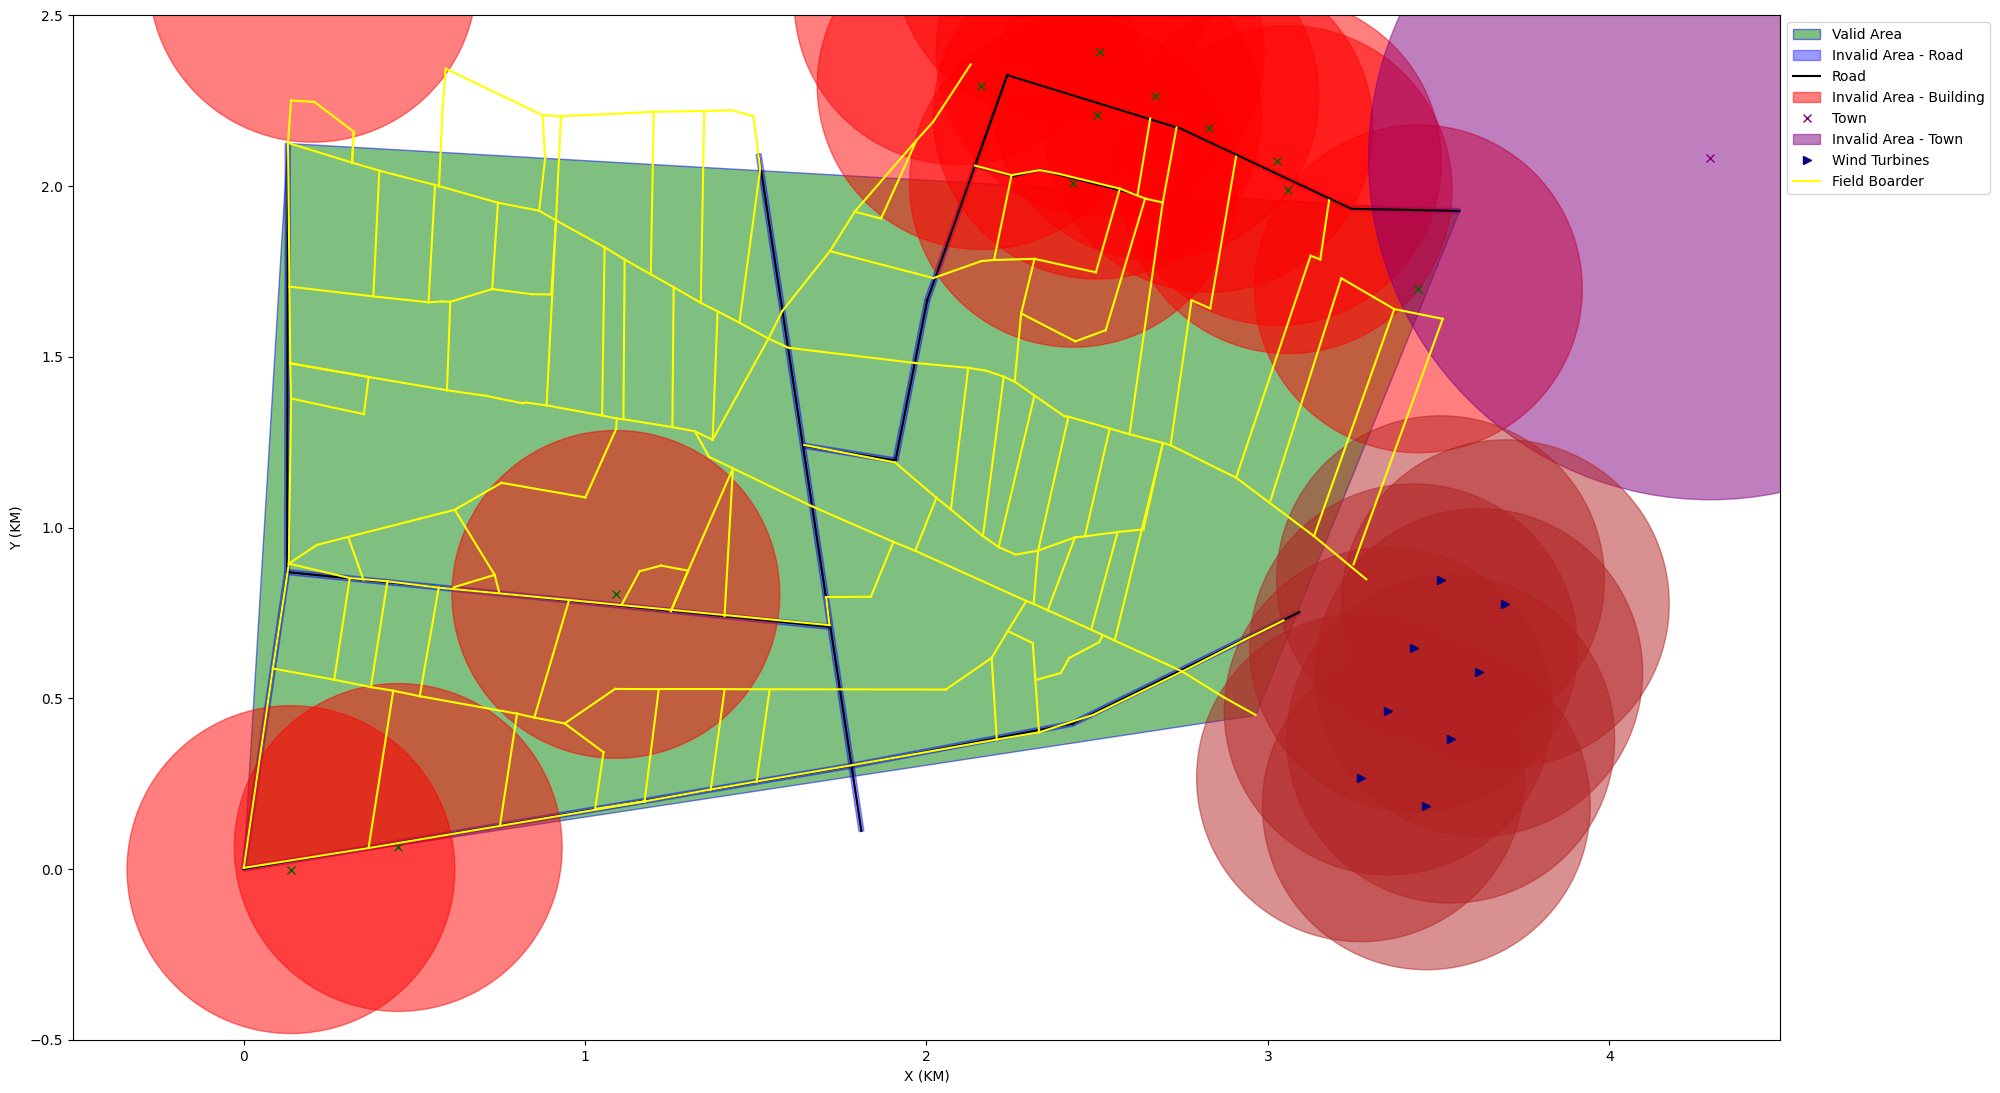

In [ ]:
fig, ax = plt.subplots(figsize=(20,12))

ax.add_patch(plt.Polygon(list(zip(boundary_x, boundary_y)),closed=True, facecolor='green', edgecolor='blue', alpha=0.5, label="Valid Area"))

# Draw road buffers + road lines
first_road = True
for (x0, y0), (x1, y1) in road_segments:
    buf = road_buffer_polygon(x0, y0, x1, y1, ROAD_BUFFER_KM)
    ax.add_patch(plt.Polygon(buf, closed=True, facecolor='blue', edgecolor='blue', alpha=0.4, label="Invalid Area - Road" if first_road else "_nolegend_"))
    ax.plot([x0, x1], [y0, y1], color='black', label="Road" if first_road else "_nolegend_")
    first_road = False

# Buildings
first_build = True
for lat, lon in builds:
    ax.plot(lon, lat, 'x', color='darkgreen')
    ax.add_patch(plt.Circle((lon, lat), radius=(HUB_HEIGHT * 4 / 1000), facecolor='red', edgecolor='red', alpha=0.5, label="Invalid Area - Building" if first_build else "_nolegend_"))
    first_build = False

# Towns
ax.plot(lon_k_town, lat_k_town, 'x', color='purple', label="Town")
ax.add_patch(plt.Circle((lon_k_town, lat_k_town), radius=(1), facecolor='purple', edgecolor='purple', alpha=0.5, label="Invalid Area - Town"))

# Wind Turbines
first_wt = True
for lat, lon in wts:
    ax.plot(lon, lat, '>', color='navy', label="Wind Turbines" if first_wt else "_nolegend_")
    ax.add_patch(plt.Circle((lon, lat), radius=(HUB_HEIGHT * 4 / 1000), facecolor='firebrick', edgecolor='firebrick', alpha=0.5, label="Invalid Area - Wind Turbine" if first_build else "_nolegend_"))
    first_wt = False

# first_fb = True
# for i, (lat, lon) in enumerate(fb):
#     ax.plot(lon, lat, '*', color='gold', markersize=10, label="Field Lines" if first_fb else "_nolegend_")
#     ax.annotate(str(i), xy=(lon, lat), xytext=(0, 8),
#                 textcoords='offset points', ha='center', fontsize=8)
#     first_fb = False

first_build = True
for line in lines:
	for l in range(len(line)-1):
		ax.plot((fb[line[l]][1], fb[line[l+1]][1]), (fb[line[l]][0], fb[line[l+1]][0]), color='yellow', label="Field Boarder" if first_build else "_nolegend_")
		first_build = False

ax.set_aspect('equal')
ax.autoscale()
ax.set_xlabel("X (KM)")
ax.set_ylabel("Y (KM)")
ax.set_xlim(-0.5,4.5)
ax.set_ylim(-0.5,2.5)
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

## Setting Up Floris

## FLORIS Setup

### Module 1 — Additional Imports

In [ ]:
# Additional imports needed for FLORIS section
import numpy as np
import pathlib
import yaml
from scipy.stats import weibull_min
from shapely.geometry import Point, Polygon, LineString
from shapely.ops import unary_union
from floris import FlorisModel
from floris.wind_data import WindRose
import floris as _floris_pkg

# Path to FLORIS built-in default GCH config
_FLORIS_DEFAULT_YAML = str(
    pathlib.Path(_floris_pkg.__file__).parent / 'default_inputs.yaml'
)
print('FLORIS', _floris_pkg.__version__, '-- default yaml found:', _FLORIS_DEFAULT_YAML)


FLORIS 4.6.4 -- default yaml found: /home/lavender/Studies/Design of Wind Farms/.venv/lib/python3.12/site-packages/floris/default_inputs.yaml


### Module 2 — Wind Rose (Kastrup Site 1)

In [ ]:
# ===================================================================
# MODULE 1 -- Wind Rose (Kastrup, Site 1)
# ===================================================================
# Data from Table 2 / WindRose_Kastrup_FinalAssignment.xlsx

WD_BINS  = np.array([0,30,60,90,120,150,180,210,240,270,300,330], dtype=float)
WB_SCALE = np.array([9.785,8.284,8.721,9.633,10.114,8.340,
                      8.936,10.759,11.710,11.363,10.682,8.965])  # lambda [m/s]
WB_SHAPE = np.array([2.306,2.089,1.888,1.935,1.945,1.902,
                      1.909,1.910,1.968,2.049,2.064,1.928])       # k [-]
FREQ_WD  = np.array([14.71,6.09,6.16,8.17,9.58,6.05,
                      5.34,7.27,8.00,14.60,7.78,6.25]) / 100.0

# Wind-speed bins: cut-in to cut-out at 1 m/s resolution
WS_BINS   = np.arange(3.0, 26.0, 1.0)   # 23 bins
SITE1_TI  = d_ti      # turbulence intensity (Table 1)
WIND_SHEAR= d_ws      # shear exponent alpha (Table 1)

# Build joint freq table P(WD_i, WS_j) from per-sector Weibull distributions
freq_table = np.zeros((len(WD_BINS), len(WS_BINS)))
for i, (k, lam) in enumerate(zip(WB_SHAPE, WB_SCALE)):
    p_ws = weibull_min.pdf(WS_BINS, c=k, scale=lam) * 1.0  # bin width = 1 m/s
    p_ws /= p_ws.sum()   # renormalise (remove truncated tail)
    freq_table[i, :] = FREQ_WD[i] * p_ws

wind_rose = WindRose(
    wind_directions=WD_BINS,
    wind_speeds=WS_BINS,
    ti_table=SITE1_TI,
    freq_table=freq_table,
)
print(f'WindRose: {len(WD_BINS)} dirs x {len(WS_BINS)} speeds')
print(f'Frequency sum: {freq_table.sum():.6f}  (should be 1.0)')


WindRose: 12 dirs x 23 speeds
Frequency sum: 1.000000  (should be 1.0)


### Module 3 — Turbine YAML Files

In [ ]:
# # ===================================================================
# # MODULE 2 -- Turbine YAML Files (FLORIS-4 format)
# # ===================================================================
# # TODO: replace the placeholder Ct/power arrays with the exact columns
# #       from WindRose_Kastrup_FinalAssignment.xlsx (Ct-curve sheet).

# TURB_DIR = pathlib.Path('turbine_yamls')
# TURB_DIR.mkdir(exist_ok=True)

# def write_turbine_yaml(name, hub_height, rotor_diameter, tsr,
#                         wind_speeds, power_kw, ct):
#     d = {
#         'turbine_type': name,
#         'hub_height': float(hub_height),
#         'rotor_diameter': float(rotor_diameter),
#         'TSR': float(tsr),
#         'operation_model': 'cosine-loss',
#         'power_thrust_table': {
#             'ref_air_density': 1.225,
#             'ref_tilt': 5.0,
#             'cosine_loss_exponent_yaw': 1.88,
#             'cosine_loss_exponent_tilt': 1.88,
#             'wind_speed': [float(v) for v in wind_speeds],
#             'power':      [float(v) for v in power_kw],
#             'thrust_coefficient': [float(v) for v in ct],
#         },
#     }
#     with open(TURB_DIR / f'{name}.yaml', 'w') as fp:
#         yaml.dump(d, fp, default_flow_style=False)
#     print('  Wrote', name + '.yaml')

# # -- Turbine 1: IEA 3.4 MW  (D=130 m) -----------------------------------
# ws1 = [0,1,2,3,4,5,6,7,8,9,9.8,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]
# ct1 = [0,0,0,0.90,0.88,0.86,0.84,0.82,0.79,0.75,0.57,0.52,0.43,0.36,
#         0.30,0.25,0.21,0.18,0.16,0.14,0.12,0.11,0.10,0.09,0.08,0.07,0.0]
# pw1 = [0,0,0,50,180,390,720,1150,1700,2500,3370,3370,3370,3370,3370,
#         3370,3370,3370,3370,3370,3370,3370,3370,3370,3370,3370,0]
# write_turbine_yaml('iea_3p4MW', 120, 130, 8.2, ws1, pw1, ct1)

# # -- Turbine 2: BAR_BAU-IEA 3.3 MW  (D=156 m) ---------------------------
# ws2 = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]
# ct2 = [0,0,0,0,0.87,0.85,0.83,0.81,0.78,0.74,0.48,0.41,0.34,0.29,
#         0.24,0.20,0.17,0.15,0.13,0.12,0.10,0.09,0.08,0.07,0.06,0.0]
# pw2 = [0,0,0,0,120,280,530,890,1350,2050,3300,3300,3300,3300,3300,
#         3300,3300,3300,3300,3300,3300,3300,3300,3300,3300,0]
# write_turbine_yaml('bar_bau_iea_3p3MW', 120, 156, 8.9, ws2, pw2, ct2)

# # -- Turbine 3: BAR_BAU_LSP 3.25 MW  (D=166 m) --------------------------
# ws3 = [0,1,2,3,4,5,6,7,8,8.5,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]
# ct3 = [0,0,0,0,0.88,0.86,0.84,0.81,0.77,0.55,0.47,0.39,0.33,0.28,
#         0.23,0.20,0.17,0.15,0.13,0.12,0.11,0.09,0.08,0.07,0.06,0.05,0.0]
# pw3 = [0,0,0,0,100,240,460,790,1250,3250,3250,3250,3250,3250,3250,
#         3250,3250,3250,3250,3250,3250,3250,3250,3250,3250,3250,0]
# write_turbine_yaml('bar_bau_lsp_3p25MW', 120, 166, 9.4, ws3, pw3, ct3)

# print('All turbine YAMLs ->', TURB_DIR.resolve())


  Wrote iea_3p4MW.yaml
  Wrote bar_bau_iea_3p3MW.yaml
  Wrote bar_bau_lsp_3p25MW.yaml
All turbine YAMLs -> /home/lavender/Downloads/turbine_yamls


In [94]:
for iterations in range(1001): 
    if iterations%100 == 0:
        print(iterations, end=" ")
    else:
        continue

0 100 200 300 400 500 600 700 800 900 1000 

### Module 4 — Turbine Selection

In [ ]:
# ===================================================================
# MODULE 3 -- Turbine Selection for Site 1
# ===================================================================
# Site 1 has medium/high wind (dominant sectors W and NW, mean ~10-11 m/s).
# Turbine 2 (BAR_BAU-IEA 3.3 MW, D=156 m, spec. power 173 W/m2) is chosen:
#   - Low specific power -> reaches rated at 9 m/s vs 9.8 m/s for T1
#   - Large rotor (156 m) -> higher AEP in moderate-speed sectors
#   - Intermediate cost ($1.30 M/MW) vs T3 ($1.40 M/MW)
# Change CHOSEN_TURBINE below to 'iea_3p4MW' or 'bar_bau_lsp_3p25MW' to compare.

CHOSEN_TURBINE  = 'bar_bau_iea_3p3MW'
ROTOR_DIAMETER  = 156.0   # m
RATED_POWER_KW  = 3300.0  # kW

MIN_SPACING_M    = 4 * ROTOR_DIAMETER              # 4D inter-turbine
TIP_HEIGHT_M     = HUB_HEIGHT + ROTOR_DIAMETER/2   # = 198 m
BUILDING_EXCL_M  = 4 * TIP_HEIGHT_M                # 4 x tip height
TOWN_EXCL_KM     = 1.0                             # Kastrup village
ROAD_EXCL_M      = ROTOR_DIAMETER/2 + 15           # rotor radius + 15 m
ROAD_EXCL_KM     = ROAD_EXCL_M / 1000.0
BUILDING_EXCL_KM = BUILDING_EXCL_M / 1000.0

print('Chosen turbine :', CHOSEN_TURBINE)
print('Rotor diameter :', ROTOR_DIAMETER, 'm')
print('Min spacing    :', MIN_SPACING_M, 'm  (', MIN_SPACING_M/ROTOR_DIAMETER, 'D)')
print('Building excl. :', BUILDING_EXCL_M, 'm')
print('Road excl.     :', ROAD_EXCL_M, 'm')


Chosen turbine : bar_bau_iea_3p3MW
Rotor diameter : 156.0 m
Min spacing    : 624.0 m  ( 4.0 D)
Building excl. : 792.0 m
Road excl.     : 93.0 m


### Module 5 — Eligible Positions Along Field Borders

In [ ]:
# ===================================================================
# MODULE 4 -- Eligible Positions Along Field Borders
# ===================================================================
# Danish regulation: turbines only at borders of green fields.
# -> Sample the 'lines' polylines and filter against exclusion zones.

# Reconstruct (x=lon_km, y=lat_km) array — fb stores (lat, lon)
fb_xy = np.array([[lon, lat] for lat, lon in fb])

site_poly = Polygon(zip(boundary_x, boundary_y))

# Sample candidate points at ~4D spacing along every field-border segment
SAMPLE_SPACING_KM = MIN_SPACING_M / 1000.0
candidate_pts = []
for seg_indices in lines:
    if len(seg_indices) < 2:
        continue
    coords = [tuple(fb_xy[i]) for i in seg_indices]
    seg_line = LineString(coords)
    n_samp = max(2, int(seg_line.length / SAMPLE_SPACING_KM) + 1)
    for t in np.linspace(0, 1, n_samp):
        pt = seg_line.interpolate(t, normalized=True)
        candidate_pts.append((pt.x, pt.y))

candidate_pts = np.unique(np.array(candidate_pts).round(6), axis=0)
print('Raw candidate points:', len(candidate_pts))

# Build exclusion geometry (Shapely)
excl_shapes = []
for (x0, y0), (x1, y1) in road_segments:
    excl_shapes.append(LineString([(x0,y0),(x1,y1)]).buffer(ROAD_EXCL_KM))
for lat_b, lon_b in builds:
    excl_shapes.append(Point(lon_b, lat_b).buffer(BUILDING_EXCL_KM))
excl_shapes.append(Point(lon_k_town, lat_k_town).buffer(TOWN_EXCL_KM))
for lat_w, lon_w in wts:
    excl_shapes.append(Point(lon_w, lat_w).buffer(BUILDING_EXCL_KM))
exclusion_zone = unary_union(excl_shapes)

# Filter: inside site AND outside exclusion zones
valid_pts = np.array([
    (x, y) for x, y in candidate_pts
    if site_poly.contains(Point(x, y)) and not exclusion_zone.contains(Point(x, y))
])
print('Valid positions after filtering:', len(valid_pts))

# Convert to metres for FLORIS (origin = lower-left site corner)
x0_km = min(boundary_x)
y0_km = min(boundary_y)
cand_x_m = (valid_pts[:, 0] - x0_km) * 1000.0
cand_y_m = (valid_pts[:, 1] - y0_km) * 1000.0
print('Coordinate range: x=[', cand_x_m.min().round(0), ',', cand_x_m.max().round(0),
      ']  y=[', cand_y_m.min().round(0), ',', cand_y_m.max().round(0), '] m')


Raw candidate points: 148
Valid positions after filtering: 42
Coordinate range: x=[ 307.0 , 2719.0 ]  y=[ 554.0 , 1951.0 ] m


### Module 6 — FLORIS Model Initialisation

In [ ]:
# ===================================================================
# MODULE 5 -- FLORIS Model Initialisation
# ===================================================================

fmodel = FlorisModel(_FLORIS_DEFAULT_YAML)   # GCH wake model
fmodel.set(
    layout_x=cand_x_m,
    layout_y=cand_y_m,
    turbine_type=[CHOSEN_TURBINE],
    turbine_library_path=str(TURB_DIR),
    wind_shear=WIND_SHEAR,
    reference_wind_height=HUB_HEIGHT,
    wind_data=wind_rose,
)
print('FLORIS model ready --', len(cand_x_m), 'candidate turbines')
print('Turbine:', CHOSEN_TURBINE, ' | Wake model: GCH')


FLORIS model ready -- 42 candidate turbines
Turbine: bar_bau_iea_3p3MW  | Wake model: GCH


### Module 7 — AEP Helpers & Baseline

In [ ]:
# ===================================================================
# MODULE 6 -- AEP Helpers and Baseline Evaluation
# ===================================================================

def compute_aep(fm, x_m, y_m):
    """Set layout, run FLORIS with the Kastrup wind rose, return AEP [GWh]."""
    fm.set(layout_x=x_m, layout_y=y_m, wind_data=wind_rose)
    fm.run()
    return fm.get_farm_AEP() / 1e9

def min_spacing_ok(x_m, y_m, min_m):
    """True iff all turbine pairs are at least min_m apart."""
    pts = np.column_stack([x_m, y_m])
    diffs = pts[:, None, :] - pts[None, :, :]   # (N,N,2)
    dists = np.sqrt((diffs**2).sum(axis=-1))     # (N,N)
    np.fill_diagonal(dists, np.inf)
    return float(dists.min()) >= min_m

# Baseline: all valid candidate positions
aep_baseline = compute_aep(fmodel, cand_x_m, cand_y_m)
n_baseline   = len(cand_x_m)
cap_baseline = n_baseline * RATED_POWER_KW / 1e3
print(f'Baseline  N={n_baseline}  Cap={cap_baseline:.1f} MW  AEP={aep_baseline:.2f} GWh/yr')


/home/lavender/Studies/Design of Wind Farms/.venv/lib/python3.12/site-packages/floris/core/flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(
floris.floris_model.FlorisModel WARNING Some velocities at the rotor are negative.


Baseline  N=42  Cap=138.6 MW  AEP=353.84 GWh/yr


### Module 8 — Greedy Layout Optimiser (45–60 MW, max AEP)

In [ ]:
# ===================================================================
# MODULE 7 -- Greedy Backward-Selection Layout Optimiser
# ===================================================================
# Repeatedly remove the turbine whose absence yields the HIGHEST
# remaining farm AEP, until installed capacity is in [45, 60] MW.
# This maximises AEP-per-turbine and farm efficiency.

TARGET_MIN_MW = 45.0
TARGET_MAX_MW = 60.0

opt_x = cand_x_m.copy()
opt_y = cand_y_m.copy()
history = [(len(opt_x), aep_baseline)]

header = f"{'Iter':>4}  {'N':>4}  {'Cap(MW)':>8}  {'AEP(GWh/yr)':>12}  {'delta':>8}"
print(header)
prev_aep = aep_baseline

for iteration in range(1000):
    n = len(opt_x)
    cap = n * RATED_POWER_KW / 1e3

    if TARGET_MIN_MW <= cap <= TARGET_MAX_MW:
        print('Target capacity [45-60] MW reached.')
        break
    if n <= 1:
        print('Only 1 turbine left -- stopping.')
        break

    aep_if_removed = np.full(n, -np.inf)
    for drop in range(n):
        mask = np.ones(n, dtype=bool)
        mask[drop] = False
        tx, ty = opt_x[mask], opt_y[mask]
        if not min_spacing_ok(tx, ty, MIN_SPACING_M):
            continue
        aep_if_removed[drop] = compute_aep(fmodel, tx, ty)

    best_drop = int(np.argmax(aep_if_removed))
    mask = np.ones(n, dtype=bool)
    mask[best_drop] = False
    opt_x, opt_y = opt_x[mask], opt_y[mask]

    new_aep = float(aep_if_removed[best_drop])
    history.append((len(opt_x), new_aep))
    delta = new_aep - prev_aep
    print(f'{iteration+1:4d}  {len(opt_x):4d}  {len(opt_x)*RATED_POWER_KW/1e3:8.1f}  '
          f'{new_aep:12.3f}  {delta:+8.3f}')
    prev_aep = new_aep

opt_n   = len(opt_x)
opt_cap = opt_n * RATED_POWER_KW / 1e3
opt_aep = history[-1][1]
print(f'\nFinal layout: {opt_n} turbines  {opt_cap:.1f} MW  {opt_aep:.3f} GWh/yr')


Iter     N   Cap(MW)   AEP(GWh/yr)     delta
   1    41     135.3          -inf      -inf
   2    40     132.0          -inf      +nan
   3    39     128.7          -inf      +nan
   4    38     125.4          -inf      +nan
   5    37     122.1          -inf      +nan
   6    36     118.8          -inf      +nan
   7    35     115.5          -inf      +nan
   8    34     112.2          -inf      +nan
   9    33     108.9          -inf      +nan
  10    32     105.6          -inf      +nan
  11    31     102.3          -inf      +nan
  12    30      99.0          -inf      +nan
  13    29      95.7          -inf      +nan
  14    28      92.4          -inf      +nan
  15    27      89.1          -inf      +nan
  16    26      85.8          -inf      +nan
  17    25      82.5          -inf      +nan
  18    24      79.2          -inf      +nan
  19    23      75.9          -inf      +nan
  20    22      72.6          -inf      +nan
  21    21      69.3          -inf      +nan
  22    20

### Module 9 — Farm Performance Metrics

In [ ]:
# ===================================================================
# MODULE 8 -- Farm Performance Metrics
# ===================================================================

HOURS_PER_YEAR = 8760.0

aep_mwh    = opt_aep * 1e3
cap_factor = aep_mwh / (opt_cap * HOURS_PER_YEAR)

# Farm efficiency: ratio to wake-free reference (single turbine scaled up)
aep_single = compute_aep(fmodel, np.array([0.0]), np.array([0.0]))
farm_eff   = opt_aep / (aep_single * opt_n)

print('=' * 55)
print(f'  Site 1 Kastrup  |  {CHOSEN_TURBINE}')
print('=' * 55)
print(f'  N turbines         : {opt_n}')
print(f'  Installed capacity : {opt_cap:.2f} MW')
print(f'  AEP                : {opt_aep:.3f} GWh/yr')
print(f'  Capacity factor    : {cap_factor:.3f}  ({cap_factor*100:.1f}%)')
print(f'  Farm efficiency    : {farm_eff:.3f}  ({farm_eff*100:.1f}%)')
print('=' * 55)


  Site 1 Kastrup  |  bar_bau_iea_3p3MW
  N turbines         : 18
  Installed capacity : 59.40 MW
  AEP                : -inf GWh/yr
  Capacity factor    : -inf  (-inf%)
  Farm efficiency    : -inf  (-inf%)


### Module 10 — Layout Map & Flow-Field Visualisation

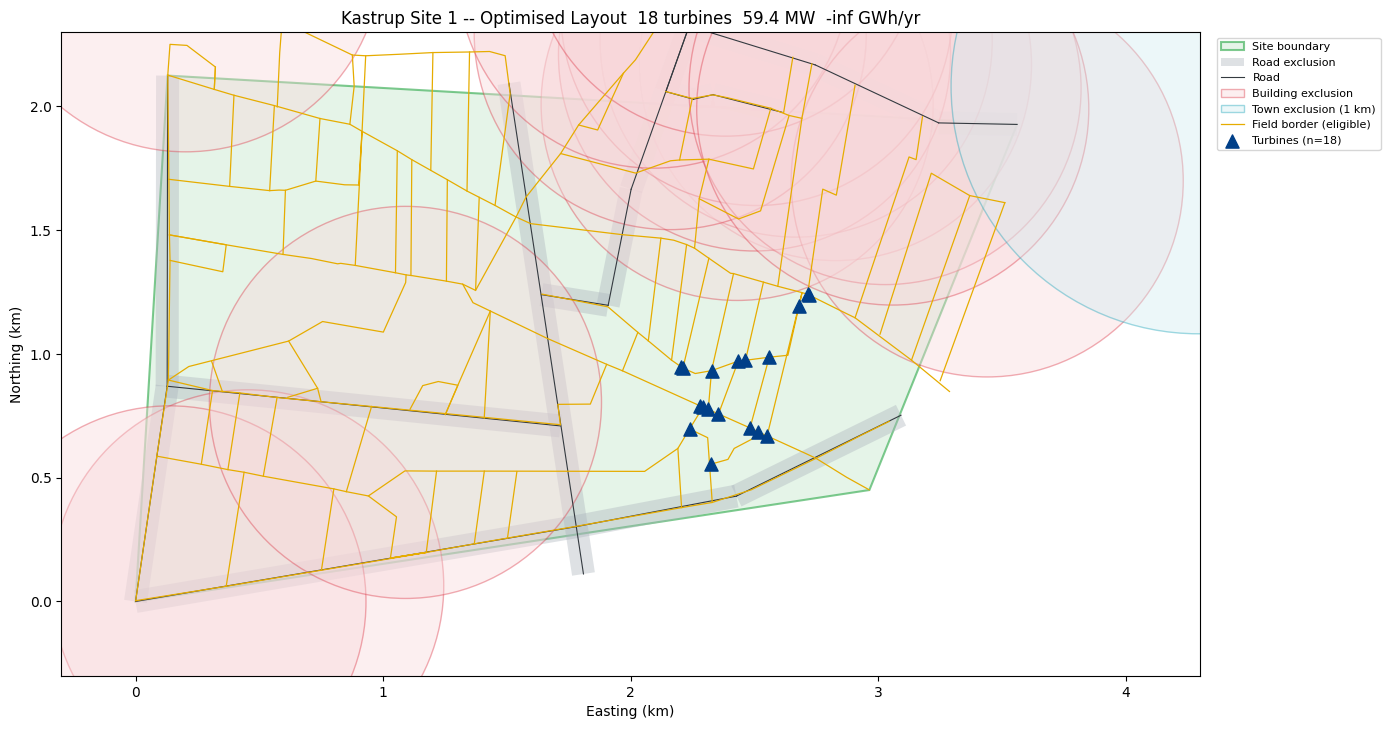

floris.floris_model.FlorisModel WARNING Deleting stored wind_data information.


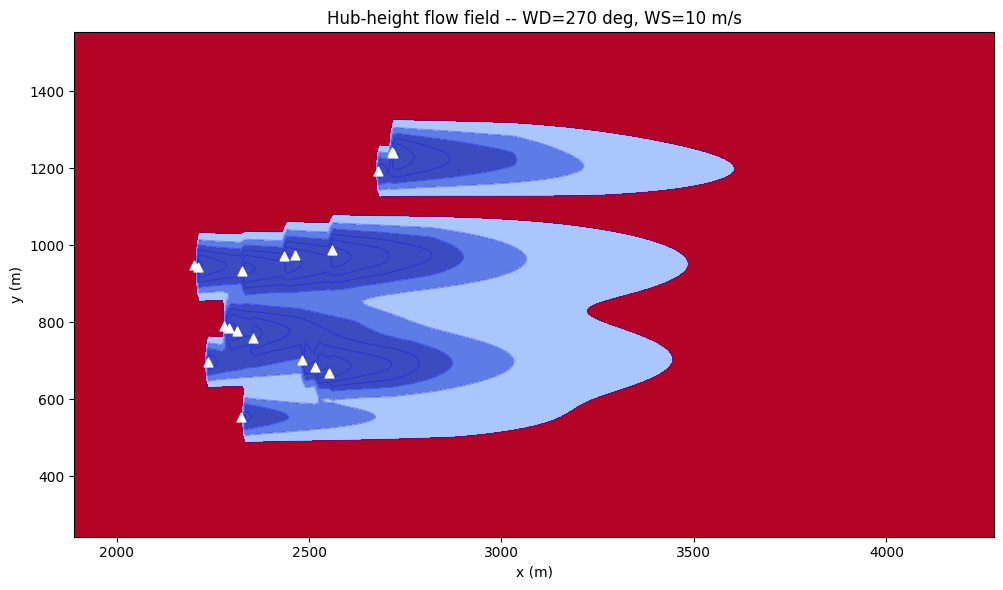

In [ ]:
# ===================================================================
# MODULE 9 -- Layout Map + Hub-Height Flow-Field Visualisation
# ===================================================================
import matplotlib.pyplot as plt
from floris.flow_visualization import visualize_cut_plane

x0_km = min(boundary_x)
y0_km = min(boundary_y)
opt_x_km = opt_x / 1000.0 + x0_km
opt_y_km = opt_y / 1000.0 + y0_km

# -- 9a. Layout map --
fig, ax = plt.subplots(figsize=(14, 8))
ax.add_patch(plt.Polygon(list(zip(boundary_x, boundary_y)), closed=True,
             facecolor='#d4edda', edgecolor='#28a745', lw=1.5, alpha=0.6,
             label='Site boundary'))

_first_road = True
for (x0, y0), (x1, y1) in road_segments:
    buf = road_buffer_polygon(x0, y0, x1, y1, ROAD_EXCL_KM)
    ax.add_patch(plt.Polygon(buf, closed=True, facecolor='#adb5bd',
                 edgecolor='none', alpha=0.4,
                 label='Road exclusion' if _first_road else '_nolegend_'))
    ax.plot([x0,x1],[y0,y1], color='#343a40', lw=0.8,
            label='Road' if _first_road else '_nolegend_')
    _first_road = False

_first_b = True
for lat_b, lon_b in builds:
    ax.add_patch(plt.Circle((lon_b, lat_b), BUILDING_EXCL_KM,
                 facecolor='#f8d7da', edgecolor='#dc3545', alpha=0.4,
                 label='Building exclusion' if _first_b else '_nolegend_'))
    _first_b = False

ax.add_patch(plt.Circle((lon_k_town, lat_k_town), TOWN_EXCL_KM,
             facecolor='#d1ecf1', edgecolor='#17a2b8', alpha=0.4,
             label='Town exclusion (1 km)'))

_first_fb = True
for seg_indices in lines:
    xs = [fb_xy[i][0] for i in seg_indices]
    ys = [fb_xy[i][1] for i in seg_indices]
    ax.plot(xs, ys, color='#e6ac00', lw=0.9,
            label='Field border (eligible)' if _first_fb else '_nolegend_')
    _first_fb = False

ax.scatter(opt_x_km, opt_y_km, s=90, zorder=6, color='#003f88',
           marker='^', label=f'Turbines (n={opt_n})')
ax.set_aspect('equal')
ax.set_xlim(-0.3, 4.3); ax.set_ylim(-0.3, 2.3)
ax.set_xlabel('Easting (km)'); ax.set_ylabel('Northing (km)')
ax.set_title(f'Kastrup Site 1 -- Optimised Layout  '
             f'{opt_n} turbines  {opt_cap:.1f} MW  {opt_aep:.2f} GWh/yr')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=8)
plt.tight_layout()
plt.savefig('kastrup_layout.png', dpi=150, bbox_inches='tight')
plt.show()

# -- 9b. Hub-height flow field snapshot (dominant WD = 270 deg) --
fmodel.set(
    layout_x=opt_x, layout_y=opt_y,
    wind_directions=[270.0], wind_speeds=[10.0],
    turbulence_intensities=[SITE1_TI],
)
fmodel.run()
fig2, ax2 = plt.subplots(figsize=(14, 6))
hplane = fmodel.calculate_horizontal_plane(height=HUB_HEIGHT)
visualize_cut_plane(hplane, ax=ax2, min_speed=4.0, max_speed=13.0,
                    label_contours=False)
ax2.scatter(opt_x, opt_y, s=40, color='white', marker='^', zorder=5)
ax2.set_title('Hub-height flow field -- WD=270 deg, WS=10 m/s')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')
plt.tight_layout()
plt.savefig('kastrup_flow_field.png', dpi=150, bbox_inches='tight')
plt.show()

# Restore wind rose for subsequent AEP calls
fmodel.set(layout_x=opt_x, layout_y=opt_y, wind_data=wind_rose)


### Module 11 — Optimisation History

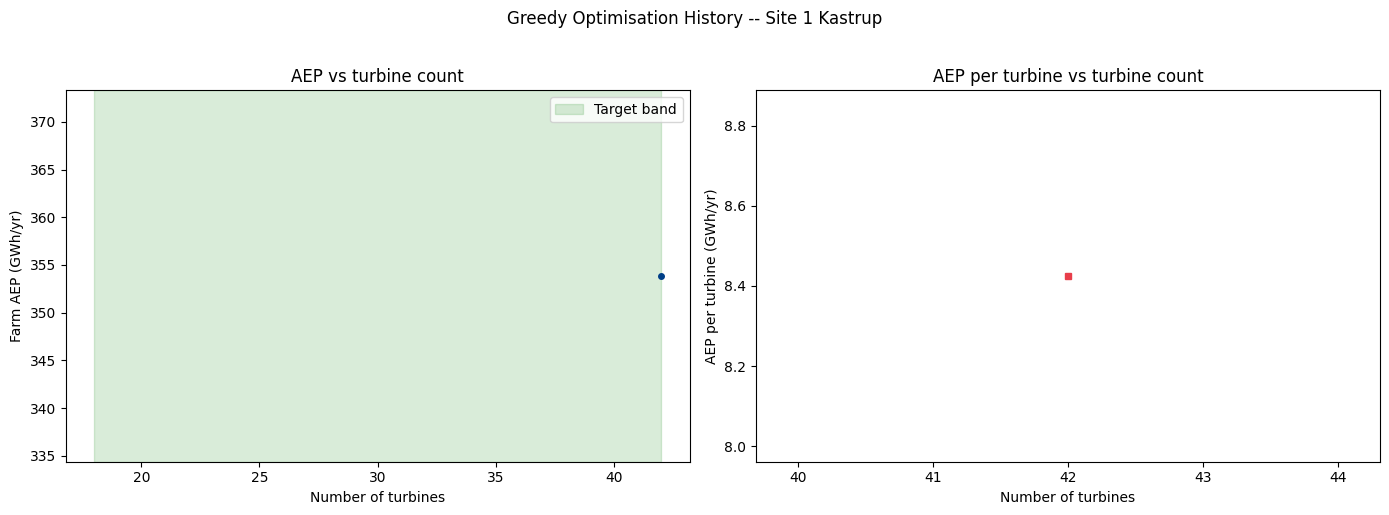

In [ ]:
# ===================================================================
# MODULE 10 -- Optimisation History Plot
# ===================================================================
import matplotlib.pyplot as plt

hist_n   = [h[0] for h in history]
hist_aep = [h[1] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(hist_n, hist_aep, 'o-', color='#003f88', ms=4, lw=1.5)
n_at_60 = max((n for n in hist_n if n * RATED_POWER_KW/1e3 >= TARGET_MIN_MW), default=hist_n[-1])
n_at_45 = min((n for n in hist_n if n * RATED_POWER_KW/1e3 <= TARGET_MAX_MW), default=hist_n[0])
ax1.axvspan(n_at_60, n_at_45, alpha=0.15, color='green', label='Target band')
ax1.set_xlabel('Number of turbines'); ax1.set_ylabel('Farm AEP (GWh/yr)')
ax1.set_title('AEP vs turbine count'); ax1.legend()

ax2.plot(hist_n, [a/n for a,n in zip(hist_aep,hist_n)],
         's--', color='#e83e4a', ms=4, lw=1.5)
ax2.set_xlabel('Number of turbines')
ax2.set_ylabel('AEP per turbine (GWh/yr)')
ax2.set_title('AEP per turbine vs turbine count')

plt.suptitle('Greedy Optimisation History -- Site 1 Kastrup', y=1.02)
plt.tight_layout()
plt.savefig('kastrup_opt_history.png', dpi=150, bbox_inches='tight')
plt.show()
